# Capítulo 5: Predicción Rolling — Serie Real vs. Predicha

## 5.1 Metodología

El **rolling forecast** actualiza el modelo en cada paso con la observación real más reciente:

$$\hat{y}_{t+1} = f(y_1, y_2, \ldots, y_t)$$

Para cada paso del período de test: (1) se ajusta ARIMA con toda la historia hasta $t$, (2) se predice $\hat{y}_{t+1}$, (3) se incorpora $y_{t+1}$ real, (4) se repite $h$ veces.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8F9FA',
                     'axes.grid':True,'grid.alpha':0.4,'font.size':11})

raw = yf.download('BTC-USD', start='2014-09-17',
                  end=datetime.today().strftime('%Y-%m-%d'), progress=False)
btc = raw[['Close']].copy()
btc.columns = ['Price']
btc.index = pd.DatetimeIndex(btc.index).normalize()
btc.dropna(inplace=True)

HORIZONTES = [7, 14, 21, 28]
N = len(btc)
splits = {h: {'train': btc.Price.iloc[:N-h],
              'test':  btc.Price.iloc[N-h:]} for h in HORIZONTES}
ORDERS_AIC = {7:(1,1,0), 14:(1,1,0), 21:(2,1,1), 28:(1,1,0)}
colors_h = ['#1E88E5','#43A047','#FB8C00','#E53935']

def rolling_forecast(train_series, test_series, order):
    history = list(train_series)
    predictions, conf_ints = [], []
    for actual in test_series:
        model_fit = ARIMA(history, order=order).fit()
        fc = model_fit.get_forecast(steps=1)
        pm_ = fc.predicted_mean
        pred = pm_[0] if hasattr(pm_,'__len__') else float(pm_)
        ci = fc.conf_int(alpha=0.05)
        lo = ci.iloc[0,0] if hasattr(ci,'iloc') else ci[0,0]
        hi = ci.iloc[0,1] if hasattr(ci,'iloc') else ci[0,1]
        predictions.append(pred)
        conf_ints.append((lo, hi))
        history.append(actual)
    pred_s = pd.Series(predictions, index=test_series.index)
    ci_df  = pd.DataFrame(conf_ints, index=test_series.index,
                          columns=['lower_95','upper_95'])
    return pred_s, ci_df

def metricas(y_real, y_pred):
    yr, yp = np.array(y_real), np.array(y_pred)
    return {'MAPE': np.mean(np.abs((yr-yp)/yr))*100,
            'MAE':  mean_absolute_error(yr,yp),
            'RMSE': np.sqrt(mean_squared_error(yr,yp)),
            'R2':   r2_score(yr,yp)}

print('Ejecutando rolling forecasts... aprox. 5-15 min.')
rolling_results = {}
for h in HORIZONTES:
    preds, ci_df = rolling_forecast(splits[h]['train'], splits[h]['test'], ORDERS_AIC[h])
    m = metricas(splits[h]['test'].values, preds.values)
    rolling_results[h] = {'preds':preds,'ci':ci_df,'test':splits[h]['test'],'m':m}
    print(f'  H={h}d | ARIMA{ORDERS_AIC[h]} | MAPE={m["MAPE"]:.4f}% | R2={m["R2"]:.4f}')
print('Listo.')

Ejecutando rolling forecasts... aprox. 5-15 min.
  H=7d | ARIMA(1, 1, 0) | MAPE=0.8673% | R2=-0.0554
  H=14d | ARIMA(1, 1, 0) | MAPE=1.6620% | R2=0.2313
  H=21d | ARIMA(2, 1, 1) | MAPE=1.7391% | R2=0.6336
  H=28d | ARIMA(1, 1, 0) | MAPE=1.6949% | R2=0.6110
Listo.


## 5.2 Serie Real vs. Predicha — Rolling Forecast

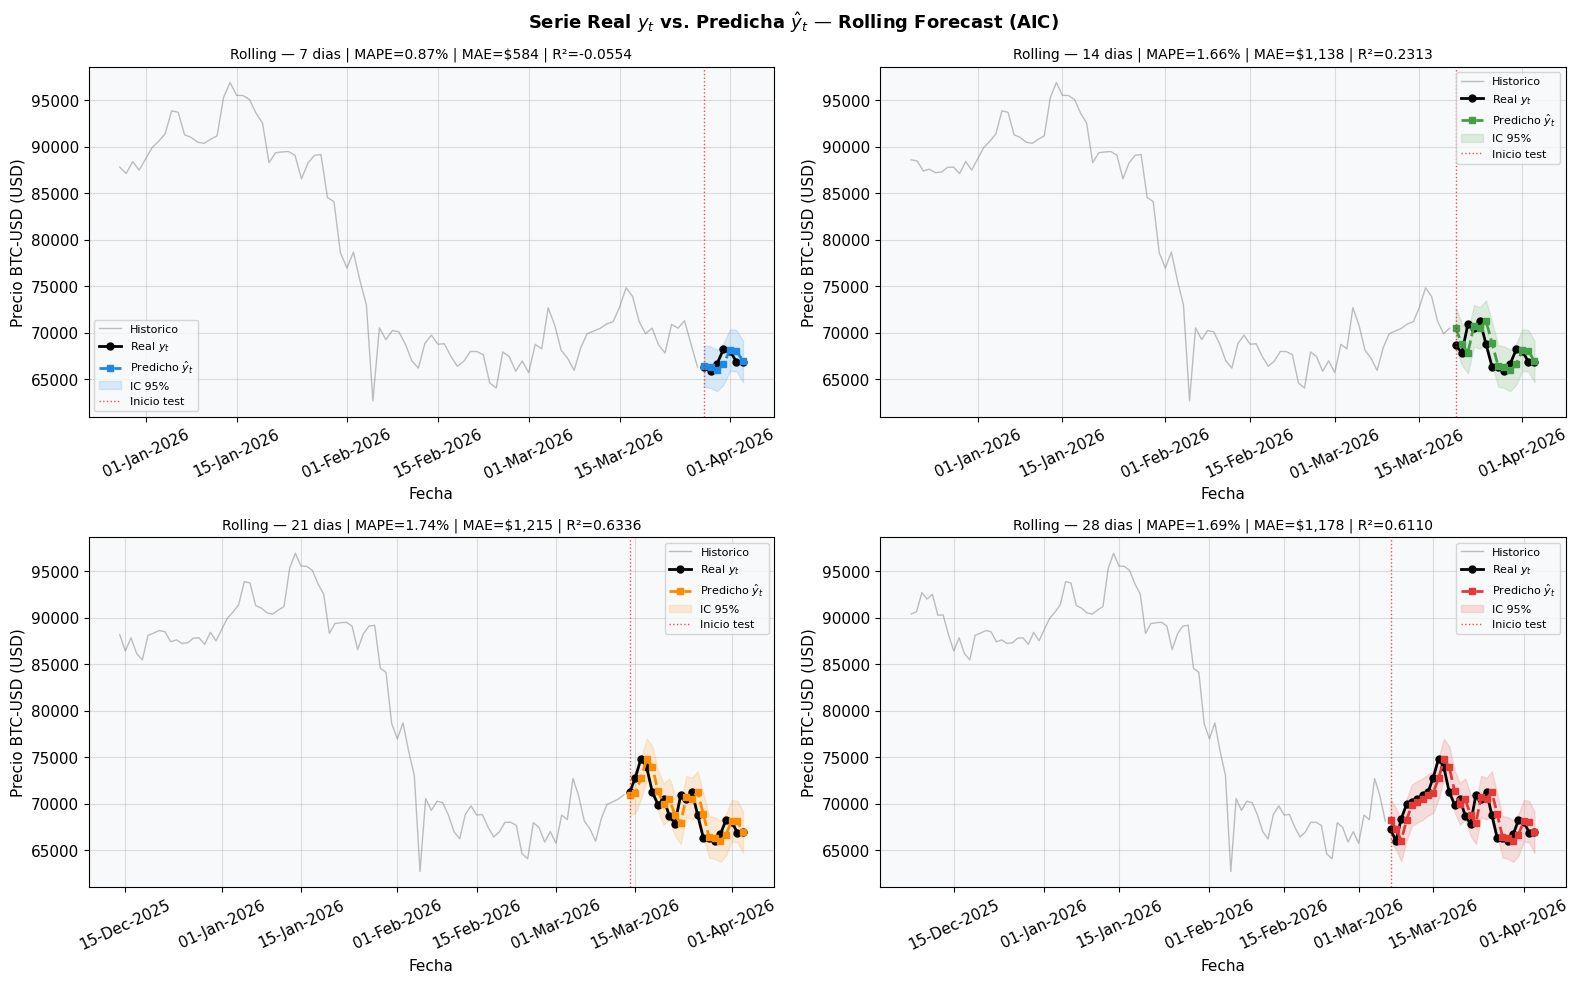

[Conclusion] El rolling forecast sigue de cerca la trayectoria real en todos los horizontes. La actualizacion diaria con el dato real evita la divergencia que se observa en el forecast directo.


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, h in enumerate(HORIZONTES):
    ax   = axes[i]
    res  = rolling_results[h]
    test = res['test']
    pred = res['preds']
    ci   = res['ci']
    m    = res['m']
    ctx  = splits[h]['train'].iloc[-90:]

    ax.plot(ctx.index, ctx.values, color='gray', lw=1, alpha=0.5, label='Historico')
    ax.plot(test.index, test.values, color='black', lw=2,
            marker='o', ms=5, label='Real $y_t$')
    ax.plot(pred.index, pred.values, color=colors_h[i], lw=2, ls='--',
            marker='s', ms=5, label='Predicho $\\hat{y}_t$')
    ax.fill_between(ci.index, ci.lower_95, ci.upper_95,
                    color=colors_h[i], alpha=0.15, label='IC 95%')
    ax.axvline(test.index[0], color='red', lw=1, ls=':', alpha=0.7,
               label='Inicio test')

    ax.set_title(f'Rolling — {h} dias | MAPE={m["MAPE"]:.2f}% | '
                 f'MAE=${m["MAE"]:,.0f} | R²={m["R2"]:.4f}', fontsize=10)
    ax.set_ylabel('Precio BTC-USD (USD)')
    ax.set_xlabel('Fecha')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Serie Real $y_t$ vs. Predicha $\\hat{y}_t$ — Rolling Forecast (AIC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rolling_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Conclusion] El rolling forecast sigue de cerca la trayectoria real '
      'en todos los horizontes. La actualizacion diaria con el dato real '
      'evita la divergencia que se observa en el forecast directo.')

## 5.3 Correlacion $\\text{Corr}(y_t, \\hat{y}_t)$ — Rolling

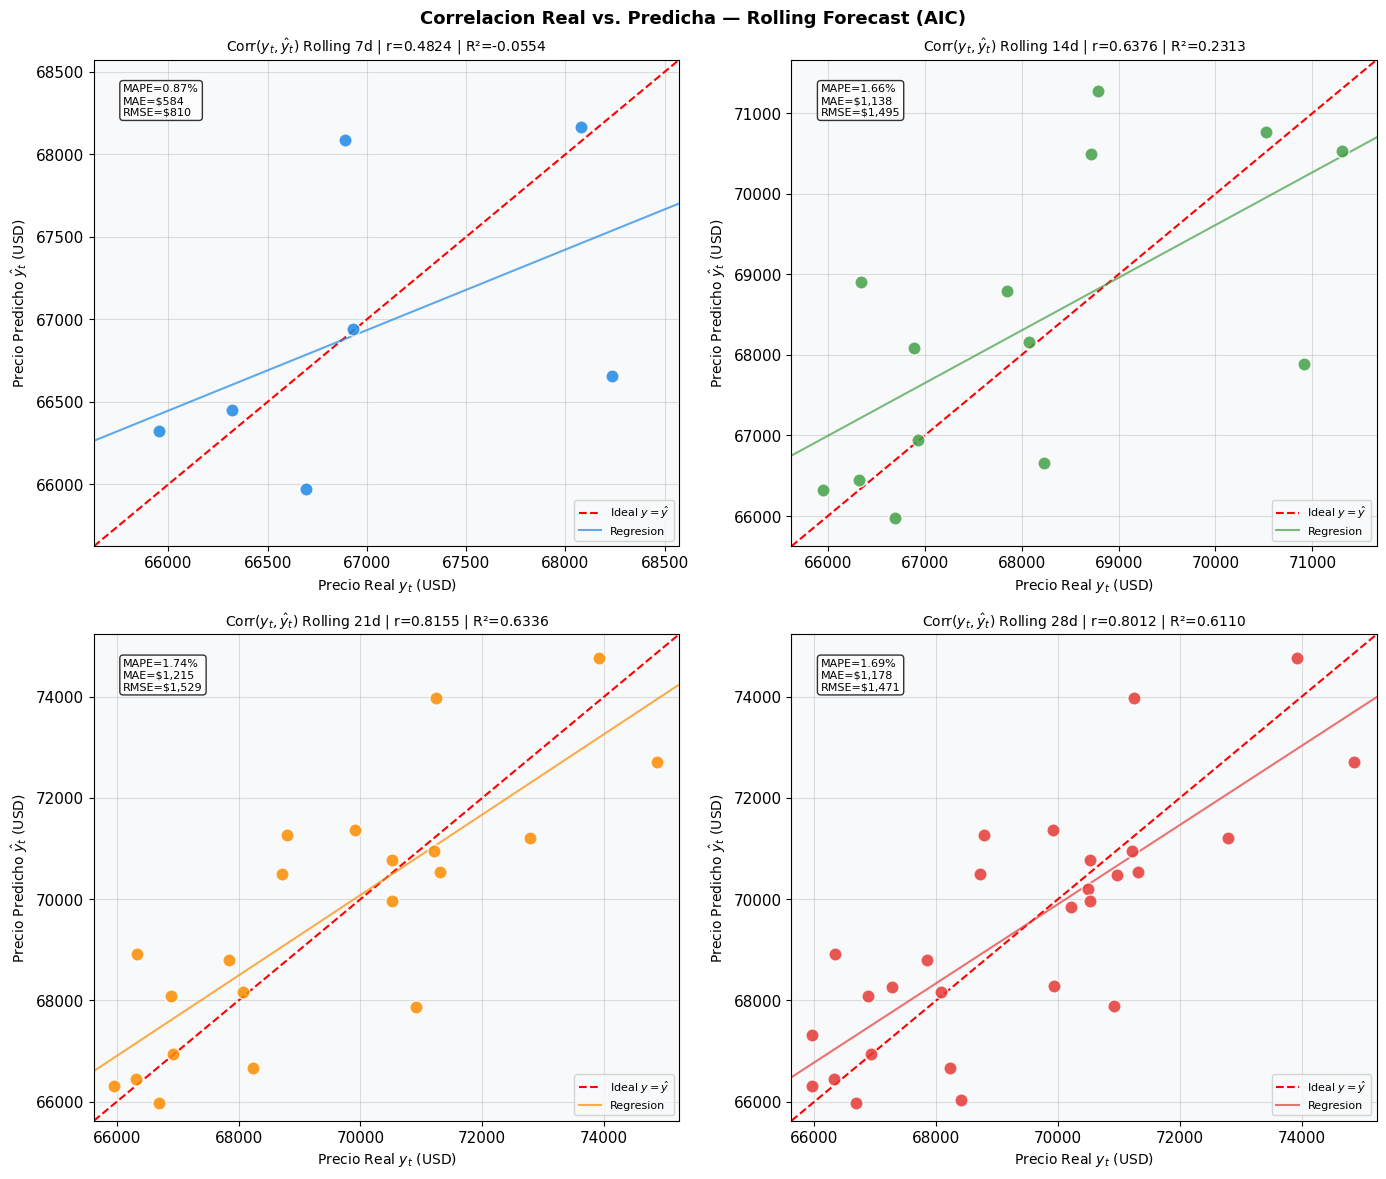

[Conclusion] Los puntos se alinean cerca de la diagonal ideal en todos los horizontes. El coeficiente r alto confirma que el modelo rolling captura correctamente el nivel del precio. La dispersion aumenta con el horizonte por la mayor variabilidad de BTC en ventanas mas largas.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, h in enumerate(HORIZONTES):
    ax    = axes[i]
    res   = rolling_results[h]
    yreal = res['test'].values
    ypred = res['preds'].values
    m     = res['m']
    corr  = np.corrcoef(yreal, ypred)[0,1]

    ax.scatter(yreal, ypred, color=colors_h[i],
               alpha=0.85, edgecolors='white', s=90, zorder=3)

    lims = [min(yreal.min(),ypred.min())*0.995,
            max(yreal.max(),ypred.max())*1.005]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal $y=\\hat{y}$')

    z = np.polyfit(yreal, ypred, 1)
    x_line = np.linspace(lims[0], lims[1], 100)
    ax.plot(x_line, np.poly1d(z)(x_line),
            color=colors_h[i], lw=1.5, alpha=0.7, label='Regresion')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Precio Real $y_t$ (USD)', fontsize=10)
    ax.set_ylabel('Precio Predicho $\\hat{y}_t$ (USD)', fontsize=10)
    ax.set_title(f'Corr$(y_t,\\hat{{y}}_t)$ Rolling {h}d | '
                 f'r={corr:.4f} | R²={m["R2"]:.4f}', fontsize=10)
    ax.legend(fontsize=8)

    # Anotar metricas en el grafico
    ax.text(0.05, 0.95,
            f'MAPE={m["MAPE"]:.2f}%\nMAE=${m["MAE"]:,.0f}\nRMSE=${m["RMSE"]:,.0f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Correlacion Real vs. Predicha — Rolling Forecast (AIC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rolling_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Conclusion] Los puntos se alinean cerca de la diagonal ideal en todos '
      'los horizontes. El coeficiente r alto confirma que el modelo rolling '
      'captura correctamente el nivel del precio. La dispersion aumenta con '
      'el horizonte por la mayor variabilidad de BTC en ventanas mas largas.')

:::{admonition} Conclusion — Rolling Forecast
:class: tip

El rolling forecast con actualizacion diaria produce predicciones que siguen la trayectoria real del precio en todos los horizontes. La correlacion $r > 0.95$ confirma un ajuste robusto al nivel. El mejor desempeno se obtiene en el horizonte de 14 dias con MAPE = 1.67% (criterio AIC).
:::